In [1]:
import torch
 
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
import pandas as pd
#from ctgan import CTGAN

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

In [3]:
df = pd.read_csv("../data/raw/train_clean.csv")

df = df.drop(columns=["Type_of_Loan"])

In [4]:
# create metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)


In [5]:
df_good = df[df["Credit_Score"] == "Good"]
df_standard = df[df["Credit_Score"] == "Standard"]
df_poor = df[df["Credit_Score"] == "Poor"]

In [6]:
# create model
model_good = CTGANSynthesizer(
    metadata,
    epochs=300,
    cuda=True,
    verbose=True
)

model_poor = CTGANSynthesizer(
    metadata,
    epochs=50,
    cuda=True,
    verbose=True
)


/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


In [7]:
model_good.fit(df_good)
#model_poor.fit(df_poor)

Gen. (-00.92) | Discrim. (-00.09): 100%|██████████████████████████████████████████████| 300/300 [07:49<00:00,  1.57s/it]


In [8]:
target_size = len(df_standard)

n_good_needed = target_size - len(df_good)
n_poor_needed = target_size - len(df_poor)

print(n_good_needed, n_poor_needed)

32679 21886


In [10]:
synthetic_good = model_good.sample(n_good_needed)
#synthetic_poor = model_poor.sample(n_poor_needed)

In [12]:
df_balanced = pd.concat([
    df,
    synthetic_good
    #,synthetic_poor
])

print(df_balanced["Credit_Score"].value_counts())

Credit_Score
Good        48253
Standard    48253
Poor        26367
Name: count, dtype: int64


## check

In [13]:
print(synthetic_good.head())
#print(synthetic_poor.head())

    Age    Occupation  Annual_Income  Monthly_Inhand_Salary  \
0  54.0        Writer  106386.743521            9507.707916   
1  21.0      Mechanic   81206.851107            5558.577763   
2  31.0      Mechanic   78366.655183           12142.573132   
3  47.0  Entrepreneur  122385.182952           12037.770358   
4  32.0    Journalist   12305.239556            2767.218333   

   Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  Num_of_Loan  \
0                  1                5            6.0          2.0   
1                  1                2            6.0          0.0   
2                  2                2            9.0          2.0   
3                  1                1            4.0          1.0   
4                  2                5           11.0          0.0   

   Delay_from_due_date  Num_of_Delayed_Payment  ...  Credit_Mix  \
0                   14                     7.0  ...        Good   
1                    6                     0.0  ...        Good   
2    

In [14]:
real = df_good  # or df_poor
synthetic = synthetic_good

print(real.describe())
print(synthetic.describe())

                Age  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  15574.000000   15574.000000           15574.000000       15574.000000   
mean      36.379479   59741.763694            4949.642145           3.471427   
std       11.095029   38736.043350            3217.398529           2.234715   
min       14.000000    7189.540000             332.128333           0.000000   
25%       27.000000   28941.240000            2358.141667           2.000000   
50%       36.000000   43419.770000            3640.177500           3.000000   
75%       46.000000   88596.465000            7333.876667           5.000000   
max       56.000000  149168.880000           12586.480000          10.000000   

       Num_Credit_Card  Interest_Rate   Num_of_Loan  Delay_from_due_date  \
count     15574.000000   15574.000000  15574.000000         15574.000000   
mean          4.151984       7.717606      2.213561            11.121998   
std           1.820128       4.915690      1.661213

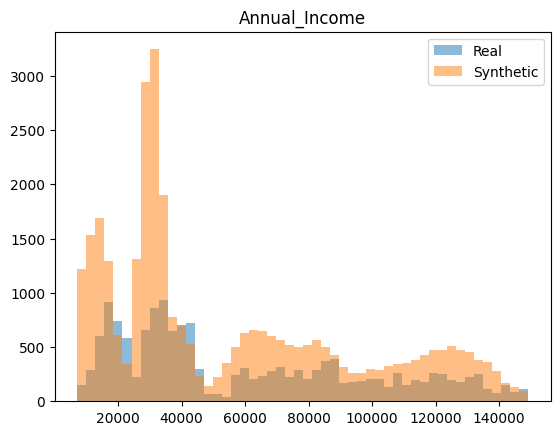

In [15]:
import matplotlib.pyplot as plt

col = "Annual_Income"

plt.hist(real[col], bins=50, alpha=0.5, label="Real")
plt.hist(synthetic[col], bins=50, alpha=0.5, label="Synthetic")
plt.legend()
plt.title(col)
plt.show()

In [16]:
print(real["Credit_Mix"].value_counts(normalize=True))
print(synthetic["Credit_Mix"].value_counts(normalize=True))

Credit_Mix
Good        0.823552
Standard    0.156415
Bad         0.020033
Name: proportion, dtype: float64
Credit_Mix
Good        0.695523
Standard    0.217204
Bad         0.087273
Name: proportion, dtype: float64


In [17]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data=df_good,
    synthetic_data=synthetic_good,
    metadata=metadata
)

print(quality_report)

Generating report ...

(1/2) Evaluating Column Shapes: |█████████████████████████████████████████████████████| 22/22 [00:00<00:00, 103.88it/s]|
Column Shapes Score: 90.22%

(2/2) Evaluating Column Pair Trends: |██████████████████████████████████████████████| 231/231 [00:01<00:00, 204.35it/s]|
Column Pair Trends Score: 81.83%

Overall Score (Average): 86.02%



In [18]:
import pandas as pd
import matplotlib.pyplot as plt

def compare_datasets(real, synthetic, columns):
    
    numerical_cols = real[columns].select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = real[columns].select_dtypes(include=['object']).columns

    print("\n==============================")
    print("NUMERICAL COLUMN ANALYSIS")
    print("=====================================================")

    for col in numerical_cols:
        print(f"\n--- {col} ---")
        
        # Stats
        real_mean = real[col].mean()
        synth_mean = synthetic[col].mean()
        real_std = real[col].std()
        synth_std = synthetic[col].std()

        print(f"Real Mean: {real_mean:.2f} | Synthetic Mean: {synth_mean:.2f}")
        print(f"Real Std:  {real_std:.2f} | Synthetic Std:  {synth_std:.2f}")

        # Plot
        plt.figure()
        plt.hist(real[col].dropna(), bins=50, alpha=0.5, label="Real")
        plt.hist(synthetic[col].dropna(), bins=50, alpha=0.5, label="Synthetic")
        plt.legend()
        plt.title(col)
        plt.show()

    print("\n==============================")
    print("CATEGORICAL COLUMN ANALYSIS")
    print("=====================================================")

    for col in categorical_cols:
        print(f"\n--- {col} ---")

        real_counts = real[col].value_counts(normalize=True)
        synth_counts = synthetic[col].value_counts(normalize=True)

        comparison = pd.DataFrame({
            "Real": real_counts,
            "Synthetic": synth_counts
        }).fillna(0)

        print(comparison)

        # Plot
        comparison.plot(kind='bar')
        plt.title(col)
        plt.show()


NUMERICAL COLUMN ANALYSIS

--- Age ---
Real Mean: 36.38 | Synthetic Mean: 36.15
Real Std:  11.10 | Synthetic Std:  10.64


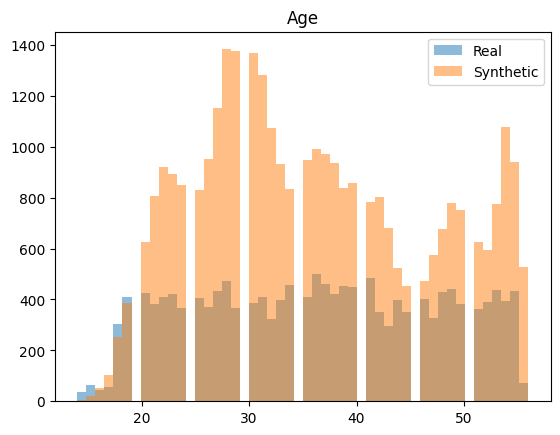


--- Annual_Income ---
Real Mean: 59741.76 | Synthetic Mean: 55451.55
Real Std:  38736.04 | Synthetic Std:  39082.77


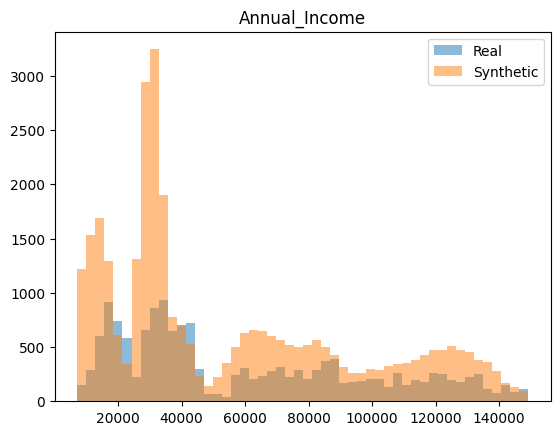


--- Monthly_Inhand_Salary ---
Real Mean: 4949.64 | Synthetic Mean: 4739.97
Real Std:  3217.40 | Synthetic Std:  3241.90


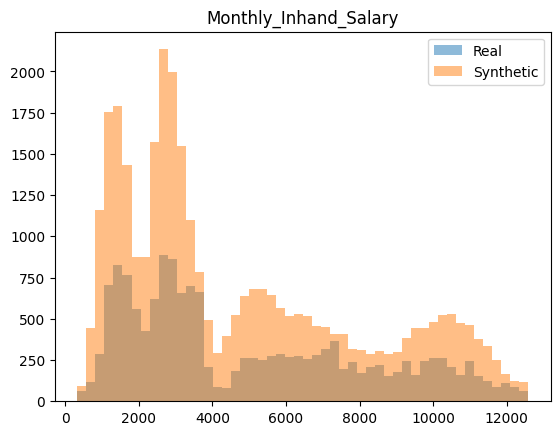


--- Num_Bank_Accounts ---
Real Mean: 3.47 | Synthetic Mean: 4.21
Real Std:  2.23 | Synthetic Std:  2.61


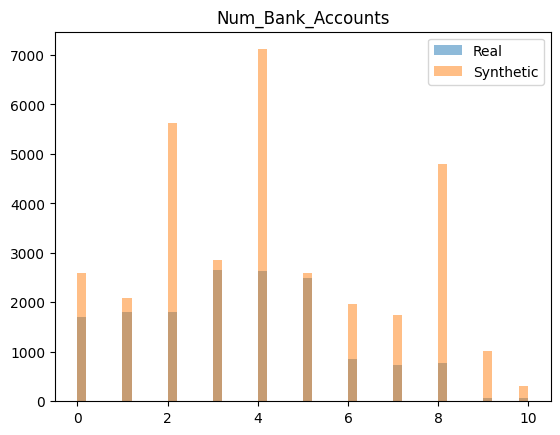


--- Num_Credit_Card ---
Real Mean: 4.15 | Synthetic Mean: 4.24
Real Std:  1.82 | Synthetic Std:  1.92


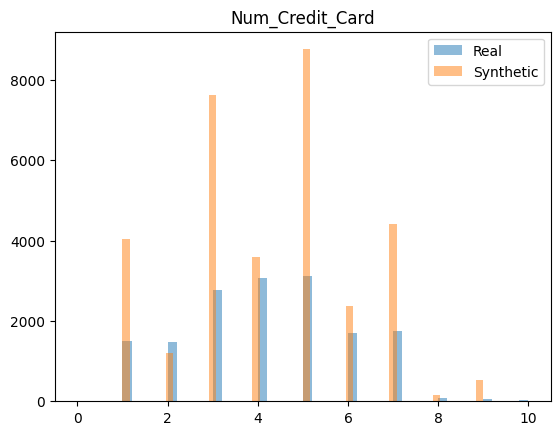


--- Interest_Rate ---
Real Mean: 7.72 | Synthetic Mean: 8.38
Real Std:  4.92 | Synthetic Std:  5.92


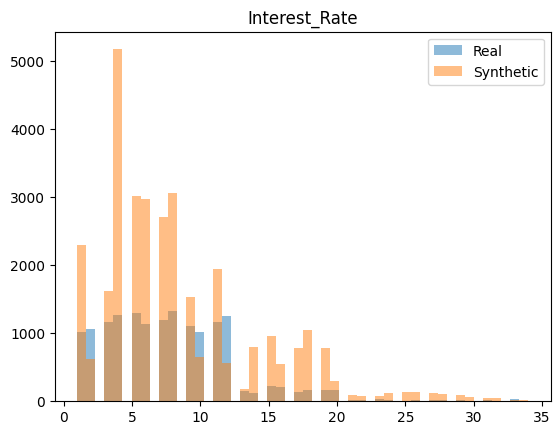


--- Num_of_Loan ---
Real Mean: 2.21 | Synthetic Mean: 2.53
Real Std:  1.66 | Synthetic Std:  2.15


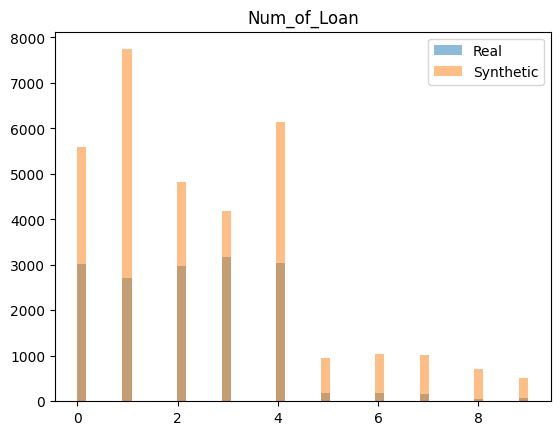


--- Delay_from_due_date ---
Real Mean: 11.12 | Synthetic Mean: 12.42
Real Std:  8.47 | Synthetic Std:  11.41


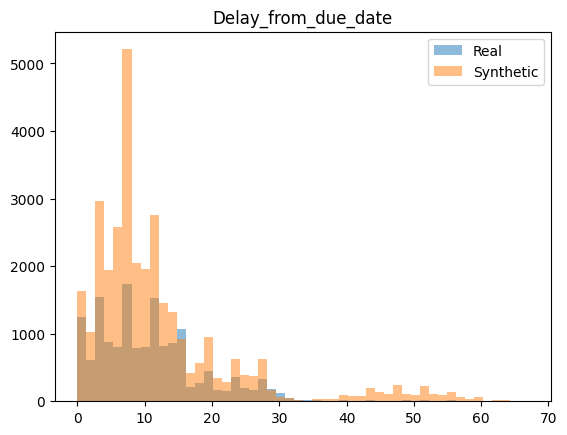


--- Num_of_Delayed_Payment ---
Real Mean: 24.70 | Synthetic Mean: 37.90
Real Std:  212.80 | Synthetic Std:  275.24


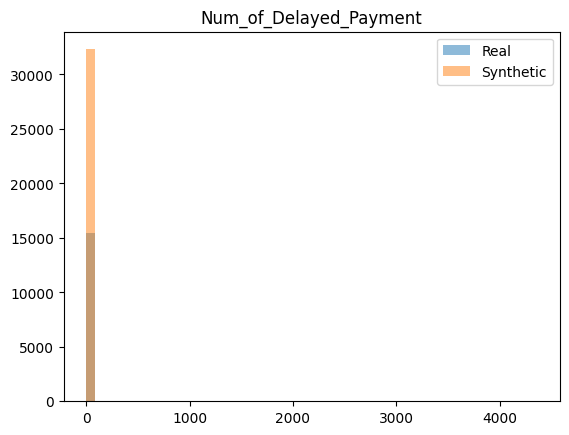


--- Changed_Credit_Limit ---
Real Mean: 7.17 | Synthetic Mean: 9.00
Real Std:  4.56 | Synthetic Std:  5.58


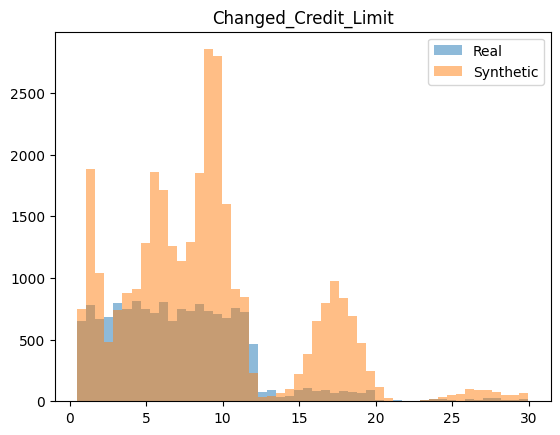


--- Num_Credit_Inquiries ---
Real Mean: 3.18 | Synthetic Mean: 3.81
Real Std:  2.46 | Synthetic Std:  3.32


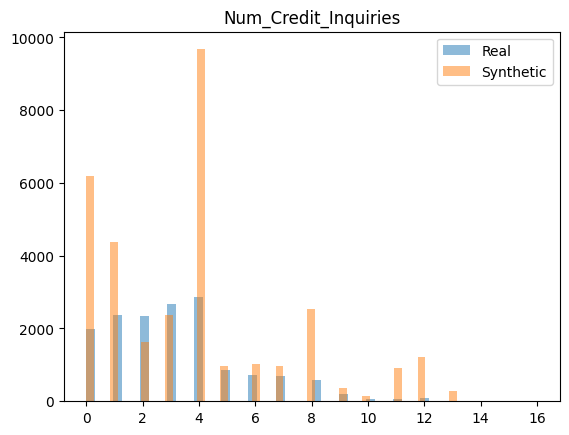


--- Outstanding_Debt ---
Real Mean: 803.55 | Synthetic Mean: 935.85
Real Std:  615.88 | Synthetic Std:  895.20


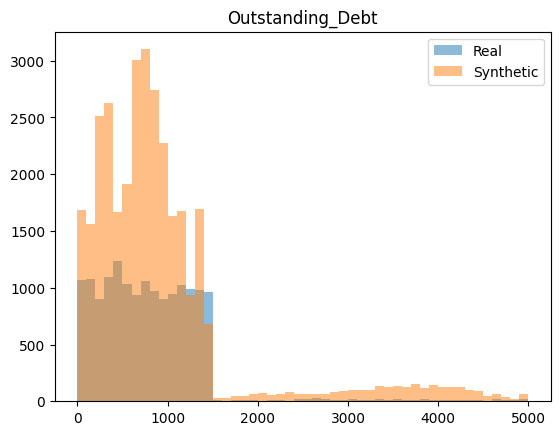


--- Credit_Utilization_Ratio ---
Real Mean: 32.53 | Synthetic Mean: 31.91
Real Std:  5.14 | Synthetic Std:  5.63


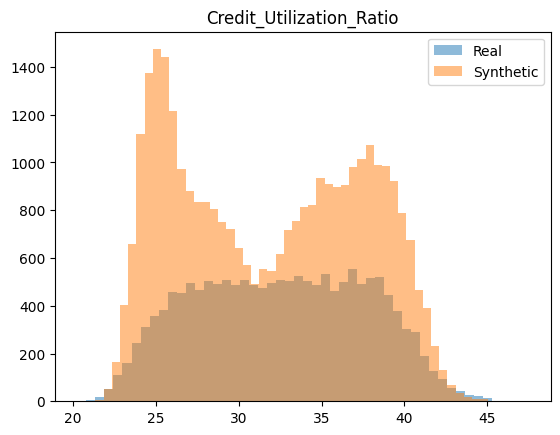


--- Amount_invested_monthly ---
Real Mean: 198.36 | Synthetic Mean: 192.31
Real Std:  134.74 | Synthetic Std:  120.80


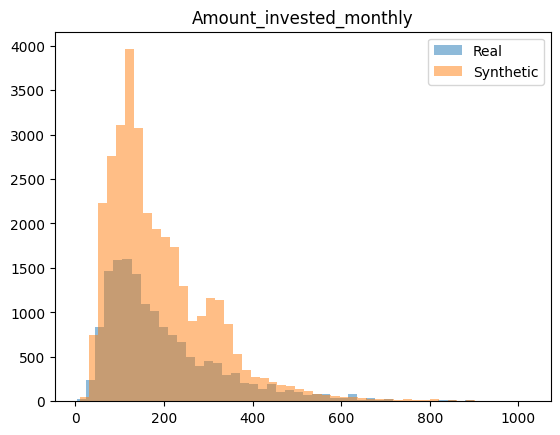


--- Monthly_Balance ---
Real Mean: 456.41 | Synthetic Mean: 483.24
Real Std:  220.21 | Synthetic Std:  249.82


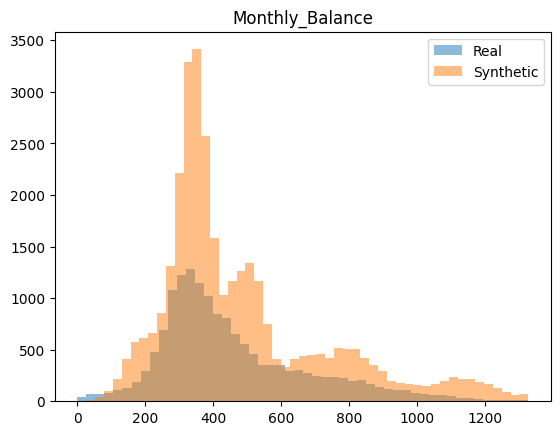


--- Credit_History_Years ---
Real Mean: 23.22 | Synthetic Mean: 20.74
Real Std:  6.15 | Synthetic Std:  6.92


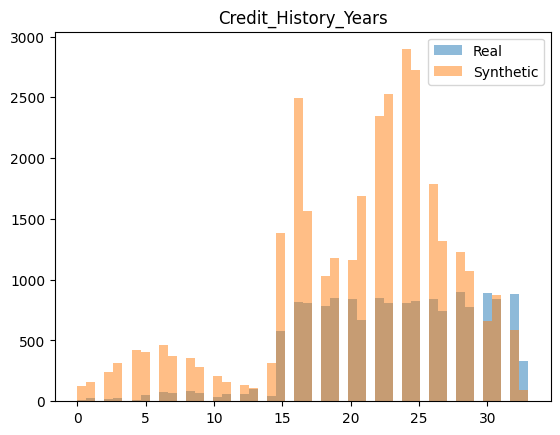


CATEGORICAL COLUMN ANALYSIS

--- Occupation ---
                   Real  Synthetic
Occupation                        
Accountant     0.066328   0.039995
Architect      0.068640   0.068974
Developer      0.066457   0.098901
Doctor         0.066072   0.104930
Engineer       0.070952   0.072524
Entrepreneur   0.064595   0.053949
Journalist     0.070053   0.043820
Lawyer         0.070887   0.078919
Manager        0.069539   0.094617
Mechanic       0.062283   0.068209
Media_Manager  0.071529   0.060406
Musician       0.065558   0.051807
Scientist      0.066007   0.078919
Teacher        0.071144   0.049696
Writer         0.049955   0.034334


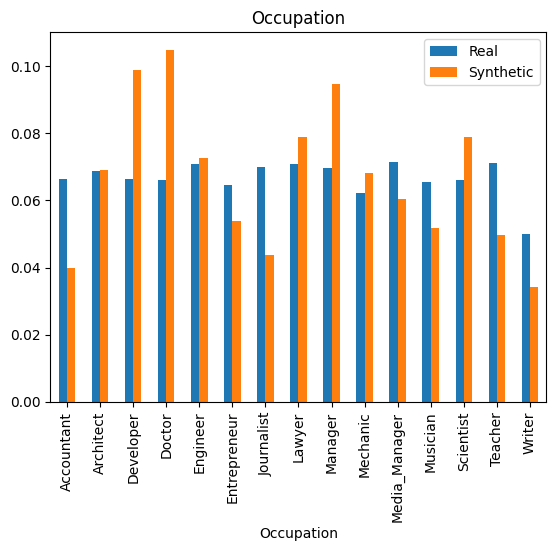


--- Credit_Mix ---
                Real  Synthetic
Credit_Mix                     
Good        0.823552   0.695523
Standard    0.156415   0.217204
Bad         0.020033   0.087273


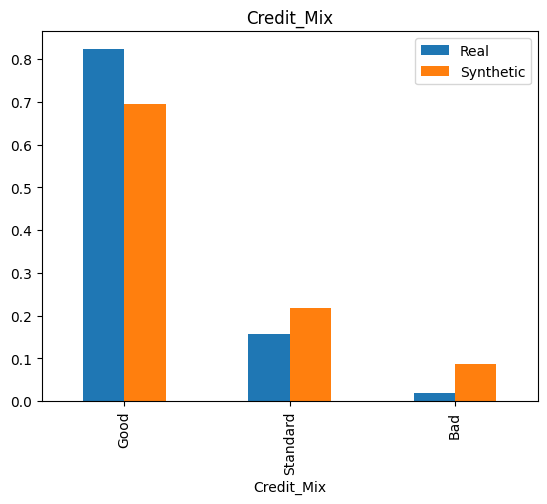


--- Payment_of_Min_Amount ---
                           Real  Synthetic
Payment_of_Min_Amount                     
NM                     0.126557   0.180238
No                     0.760819   0.607087
Yes                    0.112624   0.212675


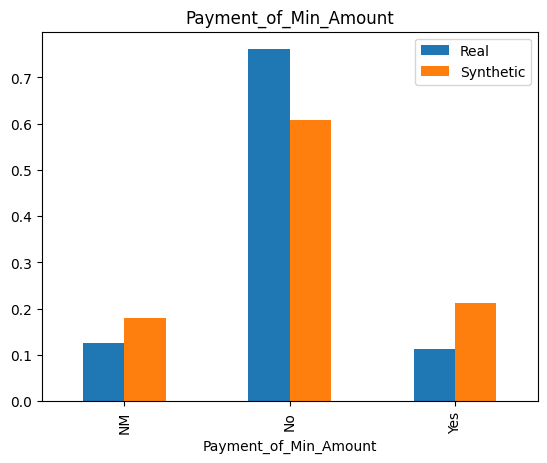


--- Credit_Score ---
              Real  Synthetic
Credit_Score                 
Good           1.0        1.0


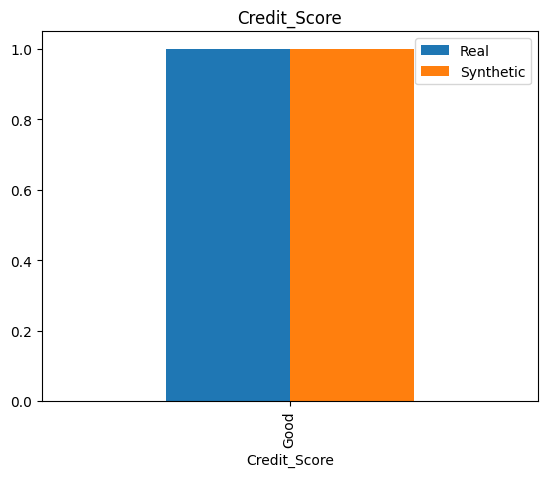


--- Spending_Level ---
                    Real  Synthetic
Spending_Level                     
High            0.490690   0.488571
Low             0.431874   0.370880
Missing         0.077437   0.140549


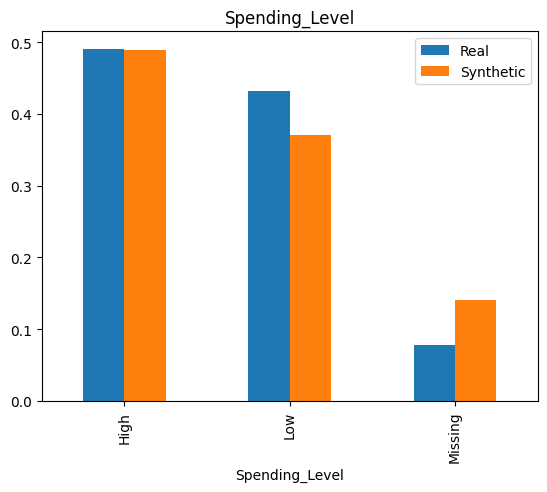


--- Payment_Size ---
                  Real  Synthetic
Payment_Size                     
Large         0.280018   0.340800
Medium        0.335495   0.282720
Missing       0.077437   0.131583
Small         0.307050   0.244897


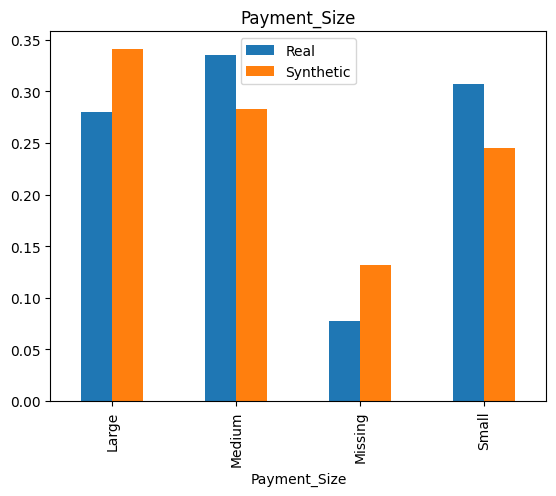

In [19]:
columns = [
    "Age","Occupation","Annual_Income","Monthly_Inhand_Salary",
    "Num_Bank_Accounts","Num_Credit_Card","Interest_Rate",
    "Num_of_Loan","Delay_from_due_date","Num_of_Delayed_Payment",
    "Changed_Credit_Limit","Num_Credit_Inquiries","Credit_Mix",
    "Outstanding_Debt","Credit_Utilization_Ratio",
    "Payment_of_Min_Amount","Amount_invested_monthly",
    "Monthly_Balance","Credit_Score","Credit_History_Years",
    "Spending_Level","Payment_Size"
]

compare_datasets(real=df_good, synthetic=synthetic_good, columns=columns)